First, we need to mount Google Drive to access its contents.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Once Google Drive is mounted, you can change the current working directory to `Level_6_AI_`.

In [4]:
import os
# Define the path to your folder in Google Drive
folder_path = '/content/drive/MyDrive/Level_6_AI_'

# Change the current working directory
os.chdir(folder_path)

# Verify the current working directory
print(f"Current working directory: {os.getcwd()}")

Current working directory: /content/drive/MyDrive/Level_6_AI_


In [6]:
import numpy as np
# Load saved numpy arrays
X_train = np.load("assets/devnagari_dataset/X_train.npy")
y_train = np.load("assets/devnagari_dataset/y_train.npy")

X_test = np.load("assets/devnagari_dataset/X_test.npy")
y_test = np.load("assets/devnagari_dataset/y_test.npy")

# Currently our data is in:
# (n_samples, 28,28) shape,
# Keras and other deep learning libraries expect it to be in:
# (n_samples, n_height, n_width, channels)
# so it wants, (n_samples, 28, 28, 1)

# keep the same number of samples (-1)

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)


print("After preprocessing:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

After preprocessing:
X_train: (17000, 28, 28, 1)
y_train: (17000,)
X_test: (3000, 28, 28, 1)
y_test: (3000,)


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


In [16]:
model = Sequential([
    # 1st conv block
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    # 2nd conv block
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # classifier
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
'''

- Epochs = 20, training set 20 times
- batch size: trains on 128 images at a time
- validation_split: hold out 20% of training data for validation

'''
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

from sklearn.utils import shuffle
X_train, y_train = shuffle(X_train, y_train, random_state=42)


X_train: (17000, 28, 28, 1)
y_train: (17000,)
X_test: (3000, 28, 28, 1)
y_test: (3000,)


In [19]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.8200 - loss: 0.5850 - val_accuracy: 0.9509 - val_loss: 0.1686
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - accuracy: 0.9690 - loss: 0.1074 - val_accuracy: 0.9744 - val_loss: 0.0955
Epoch 3/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - accuracy: 0.9831 - loss: 0.0578 - val_accuracy: 0.9779 - val_loss: 0.0713
Epoch 4/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 11s 107ms/step - accuracy: 0.9890 - loss: 0.0413 - val_accuracy: 0.9885 - val_loss: 0.0472
Epoch 5/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - accuracy: 0.9915 - loss: 0.0274 - val_accuracy: 0.9774 - val_loss: 0.0717
Epoch 6/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 12s 114ms/step - accuracy: 0.9937 - loss: 0.0231 - val_accuracy: 0.9821 - val_loss: 0.0620
Epoch 7/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - accuracy: 0.9957 - loss: 0.0151 - val_accuracy: 0.9888 - val_loss: 0.0415
Epoch 8/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - accuracy: 0.9966 - loss: 0.

In [20]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9920 - loss: 0.0375
Test loss: 0.037507664412260056
Test accuracy: 0.9919999837875366


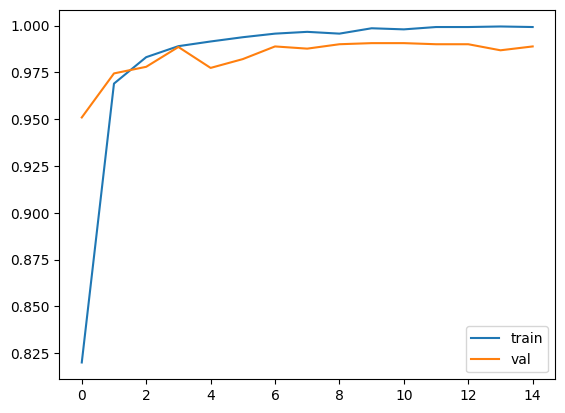

In [21]:
import matplotlib.pyplot as plt

# plot
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

# save model
model.save("week4_fcn.keras")